In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [92]:
#Сколько в таблице строк и столбцов?
users_info.shape

(1000, 4)

In [93]:
#Какие типы данных у каждого столбца?
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [94]:
#Сколько пропущенных значений в каждом столбце?
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [95]:
#Удалим все строки с пропущенными значениями. Какой процент данных был удалён?
users_info_clean = users_info[(~users_info['gender'].isnull()) & (~users_info['age'].isnull())]

In [96]:
users_info_clean.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [97]:
users_info_clean.shape

(865, 4)

In [98]:
print(f'После отчистки датасета от пропусков удалено {(1000-865)/1000*100}% данных')

После отчистки датасета от пропусков удалено 13.5% данных


In [99]:
#Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
Q1 = np.percentile(users_info_clean['age'],25)
Q3 = np.percentile(users_info_clean['age'],75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)

-6.5
85.5


In [100]:
users_info_clean = users_info_clean[users_info_clean['age'] < upper_bound]
users_info_clean

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female
...,...,...,...,...
993,1993,СПб,36.0,male
994,1994,Казань,46.0,male
995,1995,Москва,43.0,female
997,1997,СПб,58.0,male


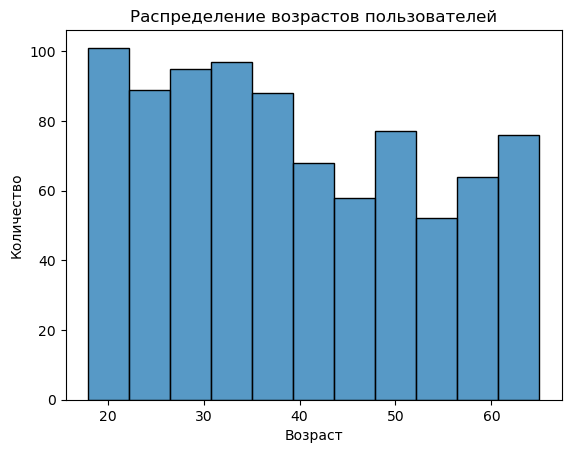

In [101]:
#Построим гистограмму (sns.histplot) распределения возрастов пользователей.
sns.histplot(users_info_clean['age'])
plt.title('Распределение возрастов пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

### Задача 2. Доля пользователей-женщин по городам

In [102]:
#Рассчитаем количество пользователей по каждому полу и городу с помощью группировки и агрегации.
users_gr = users_info_clean.groupby(['city','gender']).agg(cnt = ('id_user','count')).reset_index()
users_gr

,city,gender,cnt
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220
5,Москва,male,105
6,СПб,female,123
7,СПб,male,154


In [103]:
#Используем pivot_table, чтобы представить данные:— города в строках,— пол в столбцах.
pivot_users = pd.pivot_table(users_gr,\
                            values='cnt', \
                            index=['city'],\
                            columns='gender',\
                            fill_value=0).reset_index()
pivot_users

gender,city,female,male
0,Екатеринбург,55.0,78.0
1,Казань,53.0,77.0
2,Москва,220.0,105.0
3,СПб,123.0,154.0


In [104]:
#Для каждого города рассчитаем долю женщин среди всех пользователей.
pivot_users['female_share'] = pivot_users['female']/(pivot_users['female']+pivot_users['male'])
pivot_users

gender,city,female,male,female_share
0,Екатеринбург,55.0,78.0,0.413534
1,Казань,53.0,77.0,0.407692
2,Москва,220.0,105.0,0.676923
3,СПб,123.0,154.0,0.444043


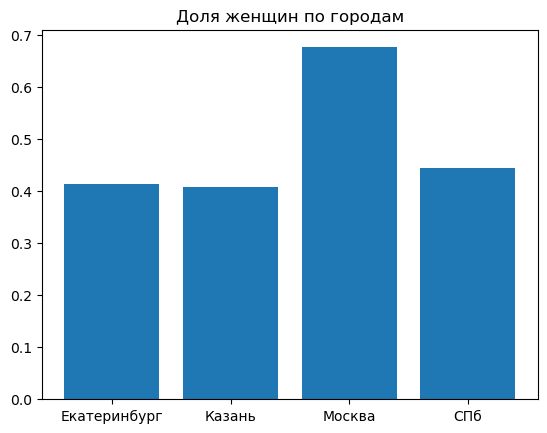

In [105]:
#Построим столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?
plt.bar(pivot_users['city'],pivot_users['female_share'])
plt.title('Доля женщин по городам')
plt.show()

Москва отличает по доле женщин среди пользователей относитьельно других городов

### Задача 3. Делим пользователей на бины

In [106]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200
...,...,...,...,...,...,...,...,...
5288,1998,2023-03,2,0,1600,0,2,1600
5289,1998,2023-04,6,0,4800,0,6,4800
5290,1998,2023-05,4,0,3200,0,4,3200
5291,1998,2023-06,6,0,4800,0,6,4800


In [107]:
#Рассчитаем среднее количество тренировок в месяц для каждого пользователя.
pay_mon = pay_mon.groupby('id_user').agg(cnt_av = ('cnt_total','mean')).reset_index()
pay_mon

,id_user,cnt_av
0,1000,3.666667
1,1001,11.727273
2,1002,11.636364
3,1003,5.166667
4,1004,2.000000
...,...,...
964,1994,7.000000
965,1995,11.500000
966,1996,1.500000
967,1997,5.000000


In [108]:
#Разделим пользователей на три группы по уровню активности
group_names = ['мало','средне','много']
pay_mon['user_type'] = pd.cut(pay_mon['cnt_av'], bins=3,labels = group_names)
pay_mon

,id_user,cnt_av,user_type
0,1000,3.666667,мало
1,1001,11.727273,средне
2,1002,11.636364,средне
3,1003,5.166667,мало
4,1004,2.000000,мало
...,...,...,...
964,1994,7.000000,средне
965,1995,11.500000,средне
966,1996,1.500000,мало
967,1997,5.000000,мало


In [109]:
print(f'Тренируются много: {pay_mon[pay_mon['user_type']=='много'].count().iloc[0]} пользователей')
print(f'Тренируются средне: {pay_mon[pay_mon['user_type']=='средне'].count().iloc[0]} пользователей')
print(f'Тренируются мало: {pay_mon[pay_mon['user_type']=='мало'].count().iloc[0]} пользователей')

Тренируются много: 53 пользователей
Тренируются средне: 319 пользователей
Тренируются мало: 597 пользователей
